# Challenge Telecom X - Parte 2: Predicción de Churn


In [1]:
#Importamos bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#Para mejorar la calidad de nuestros gráficos
%matplotlib inline
sns.set(style="whitegrid")

In [3]:
#cargamos el archivo csv previamente ordenado y limpiado (TelecomX Parte 1)
df = pd.read_csv('telecomx_limpio.csv')

#verificación de data frame
print(f" el dataset tiene {df.shape[0]} registros.")
df.head()

 el dataset tiene 7032 registros.


,customer_id,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


# 🛠️ 1. Preparación de los Datos para Machine Learning


##Eliminación de Columnas Irrelevantes

In [4]:
# El ID del cliente no es de utilidad en este análisis, por lo que eliminamos la columana
# eliminar columna identificadora:
df = df.drop("customer_id", axis=1)

# verificar columnas restantes
df.columns

Index(['churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total'],
      dtype='object')

##Encoding: Transformación de Variables Categóricas

Los modelos de Machine Learning solo trabajan con números, así que las variables categóricas (texto) deben transformarse.

In [5]:
#Revisamos qué columnas son categóricas:
df.select_dtypes(include="object").columns


Index(['churn', 'customer_gender', 'customer_partner', 'customer_dependents',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod'],
      dtype='object')

Para transformar estas variables en un formato compatible con los modelos predictivos, se aplicó One-Hot Encoding utilizando la función get_dummies() de la biblioteca pandas.

Este método crea variables binarias (0 o 1) para cada categoría presente en las variables categóricas, permitiendo que los modelos interpreten correctamente la información contenida en estos atributos.



In [9]:
#Aplicamos One-Hot Encoding
#usamos drop_first=True para evitar multicolinealidad
df = pd.get_dummies(df, drop_first=True)
#verificamos
df.head()

,customer_seniorcitizen,customer_tenure,account_charges_monthly,account_charges_total,churn_Yes,customer_gender_Male,customer_partner_Yes,customer_dependents_Yes,phone_phoneservice_Yes,phone_multiplelines_No phone service,...,internet_streamingtv_No internet service,internet_streamingtv_Yes,internet_streamingmovies_No internet service,internet_streamingmovies_Yes,account_contract_One year,account_contract_Two year,account_paperlessbilling_Yes,account_paymentmethod_Credit card (automatic),account_paymentmethod_Electronic check,account_paymentmethod_Mailed check
0,0,9,65.6,593.30,False,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,False,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,True,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


In [11]:
df.shape #Ahora tenemos más columnas ya que cada categoría se volvió una variable

(7032, 31)

In [14]:
df.columns.tolist() #Al convertir las categorías ahora nuestra variable objetivo es churn yes

['customer_seniorcitizen',
 'customer_tenure',
 'account_charges_monthly',
 'account_charges_total',
 'churn_Yes',
 'customer_gender_Male',
 'customer_partner_Yes',
 'customer_dependents_Yes',
 'phone_phoneservice_Yes',
 'phone_multiplelines_No phone service',
 'phone_multiplelines_Yes',
 'internet_internetservice_Fiber optic',
 'internet_internetservice_No',
 'internet_onlinesecurity_No internet service',
 'internet_onlinesecurity_Yes',
 'internet_onlinebackup_No internet service',
 'internet_onlinebackup_Yes',
 'internet_deviceprotection_No internet service',
 'internet_deviceprotection_Yes',
 'internet_techsupport_No internet service',
 'internet_techsupport_Yes',
 'internet_streamingtv_No internet service',
 'internet_streamingtv_Yes',
 'internet_streamingmovies_No internet service',
 'internet_streamingmovies_Yes',
 'account_contract_One year',
 'account_contract_Two year',
 'account_paperlessbilling_Yes',
 'account_paymentmethod_Credit card (automatic)',
 'account_paymentmethod_E

churn queda binaria:

0 = cliente activo

1 = cliente que canceló

In [16]:
#volvemos a cambiar el nombre a churn para que sea más claro
df = df.rename(columns={"churn_Yes": "churn"})
df.columns.tolist()

['customer_seniorcitizen',
 'customer_tenure',
 'account_charges_monthly',
 'account_charges_total',
 'churn',
 'customer_gender_Male',
 'customer_partner_Yes',
 'customer_dependents_Yes',
 'phone_phoneservice_Yes',
 'phone_multiplelines_No phone service',
 'phone_multiplelines_Yes',
 'internet_internetservice_Fiber optic',
 'internet_internetservice_No',
 'internet_onlinesecurity_No internet service',
 'internet_onlinesecurity_Yes',
 'internet_onlinebackup_No internet service',
 'internet_onlinebackup_Yes',
 'internet_deviceprotection_No internet service',
 'internet_deviceprotection_Yes',
 'internet_techsupport_No internet service',
 'internet_techsupport_Yes',
 'internet_streamingtv_No internet service',
 'internet_streamingtv_Yes',
 'internet_streamingmovies_No internet service',
 'internet_streamingmovies_Yes',
 'account_contract_One year',
 'account_contract_Two year',
 'account_paperlessbilling_Yes',
 'account_paymentmethod_Credit card (automatic)',
 'account_paymentmethod_Elect

##Proporción y Balance

Proporción de clientes que cancelaron en relación con los que permanecieron activos.

Este análisis permite verificar si existe un desbalance entre las clases, ya que una proporción muy desigual entre clientes que cancelan y clientes que permanecen puede influir en el desempeño de los modelos predictivos.

A partir de esta evaluación, es posible considerar posteriormente estrategias de validación o balanceo de datos en caso de que el desbalance sea significativo.


In [17]:
#proporción
df["churn"].value_counts()

,count
churn,
False,5163
True,1869


In [19]:
#sacmos proporción en porcentajes
df["churn"].value_counts(normalize=True)*100

,proportion
churn,
False,73.421502
True,26.578498


###Tabla de Proporción

| churn     | proporción |
| --------- | ---------- |
| **False** | **73.42%** |
| **True**  | **26.58%** |

-73.4% de los clientes no cancelaron

-26.6% de los clientes sí cancelaron


Observamos un desbalance moderado en nuestras proporciones, ya que son más clientes los que no cancelan. Aunque este desbalance no es muy grande como para usar técnicas de balanceo como SMOTE, es importante considerarlo en los análisis más adelante.

##Normalización o estandarización de las variables usando StandardScaler

Algunas variables están en escalas diferentes, por lo que es importante ponerlas en la misma escala para que no afecte nuestros modelos más adelante.

Para esto se creó una versión estandarizada de los datos (X_scaled) que contiene todas las vaariables menos churn, por si usamos modelos más adelante que sean sensibles a la escala.

In [22]:
#importamos
from sklearn.preprocessing import StandardScaler

In [24]:
X = df.drop("churn", axis=1) #todas las variables excepto churn
y = df["churn"] #la variable que queremos predicir en este trabajo

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🎯 2. Correlación y Selección de Variables


##Análisis de Correlación

In [25]:
#matriz de correlación
corr = df.corr()
corr

,customer_seniorcitizen,customer_tenure,account_charges_monthly,account_charges_total,churn,customer_gender_Male,customer_partner_Yes,customer_dependents_Yes,phone_phoneservice_Yes,phone_multiplelines_No phone service,...,internet_streamingtv_No internet service,internet_streamingtv_Yes,internet_streamingmovies_No internet service,internet_streamingmovies_Yes,account_contract_One year,account_contract_Two year,account_paperlessbilling_Yes,account_paymentmethod_Credit card (automatic),account_paymentmethod_Electronic check,account_paymentmethod_Mailed check
customer_seniorcitizen,1.000000,0.015683,0.219874,0.102411,0.150541,-0.001819,0.016957,-0.210550,0.008392,-0.008392,...,-0.182519,0.105445,-0.182519,0.119842,-0.046491,-0.116205,0.156258,-0.024359,0.171322,-0.152987
customer_tenure,0.015683,1.000000,0.246862,0.825880,-0.354049,0.005285,0.381912,0.163386,0.007877,-0.007877,...,-0.037529,0.280264,-0.037529,0.285402,0.202338,0.563801,0.004823,0.232800,-0.210197,-0.232181
account_charges_monthly,0.219874,0.246862,1.000000,0.651065,0.192858,-0.013779,0.097825,-0.112343,0.248033,-0.248033,...,-0.763191,0.629668,-0.763191,0.627235,0.004810,-0.073256,0.351930,0.030055,0.271117,-0.376568
account_charges_total,0.102411,0.825880,0.651065,1.000000,-0.199484,0.000048,0.319072,0.064653,0.113008,-0.113008,...,-0.374878,0.515709,-0.374878,0.519867,0.170569,0.358036,0.157830,0.182663,-0.060436,-0.294708
churn,0.150541,-0.354049,0.192858,-0.199484,1.000000,-0.008545,-0.149982,-0.163128,0.011691,-0.011691,...,-0.227578,0.063254,-0.227578,0.060860,-0.178225,-0.301552,0.191454,-0.134687,0.301455,-0.090773
customer_gender_Male,-0.001819,0.005285,-0.013779,0.000048,-0.008545,1.000000,-0.001379,0.010349,-0.007515,0.007515,...,0.004745,-0.007124,0.004745,-0.010105,0.007755,-0.003603,-0.011902,0.001632,0.000844,0.013199
customer_partner_Yes,0.016957,0.381912,0.097825,0.319072,-0.149982,-0.001379,1.000000,0.452269,0.018397,-0.018397,...,-0.000286,0.124483,-0.000286,0.118108,0.083067,0.247334,-0.013957,0.082327,-0.083207,-0.096948
customer_dependents_Yes,-0.210550,0.163386,-0.112343,0.064653,-0.163128,0.010349,0.452269,1.000000,-0.001078,0.001078,...,0.138383,-0.016499,0.138383,-0.038375,0.069222,0.201699,-0.110131,0.061134,-0.149274,0.056448
phone_phoneservice_Yes,0.008392,0.007877,0.248033,0.113008,0.011691,-0.007515,0.018397,-0.001078,1.000000,-1.000000,...,0.171817,-0.021383,0.171817,-0.033477,-0.003142,0.004442,0.016696,-0.006916,0.002747,-0.004463
phone_multiplelines_No phone service,-0.008392,-0.007877,-0.248033,-0.113008,-0.011691,0.007515,-0.018397,0.001078,-1.000000,1.000000,...,-0.171817,0.021383,-0.171817,0.033477,0.003142,-0.004442,-0.016696,0.006916,-0.002747,0.004463


###Heatmap de correlación

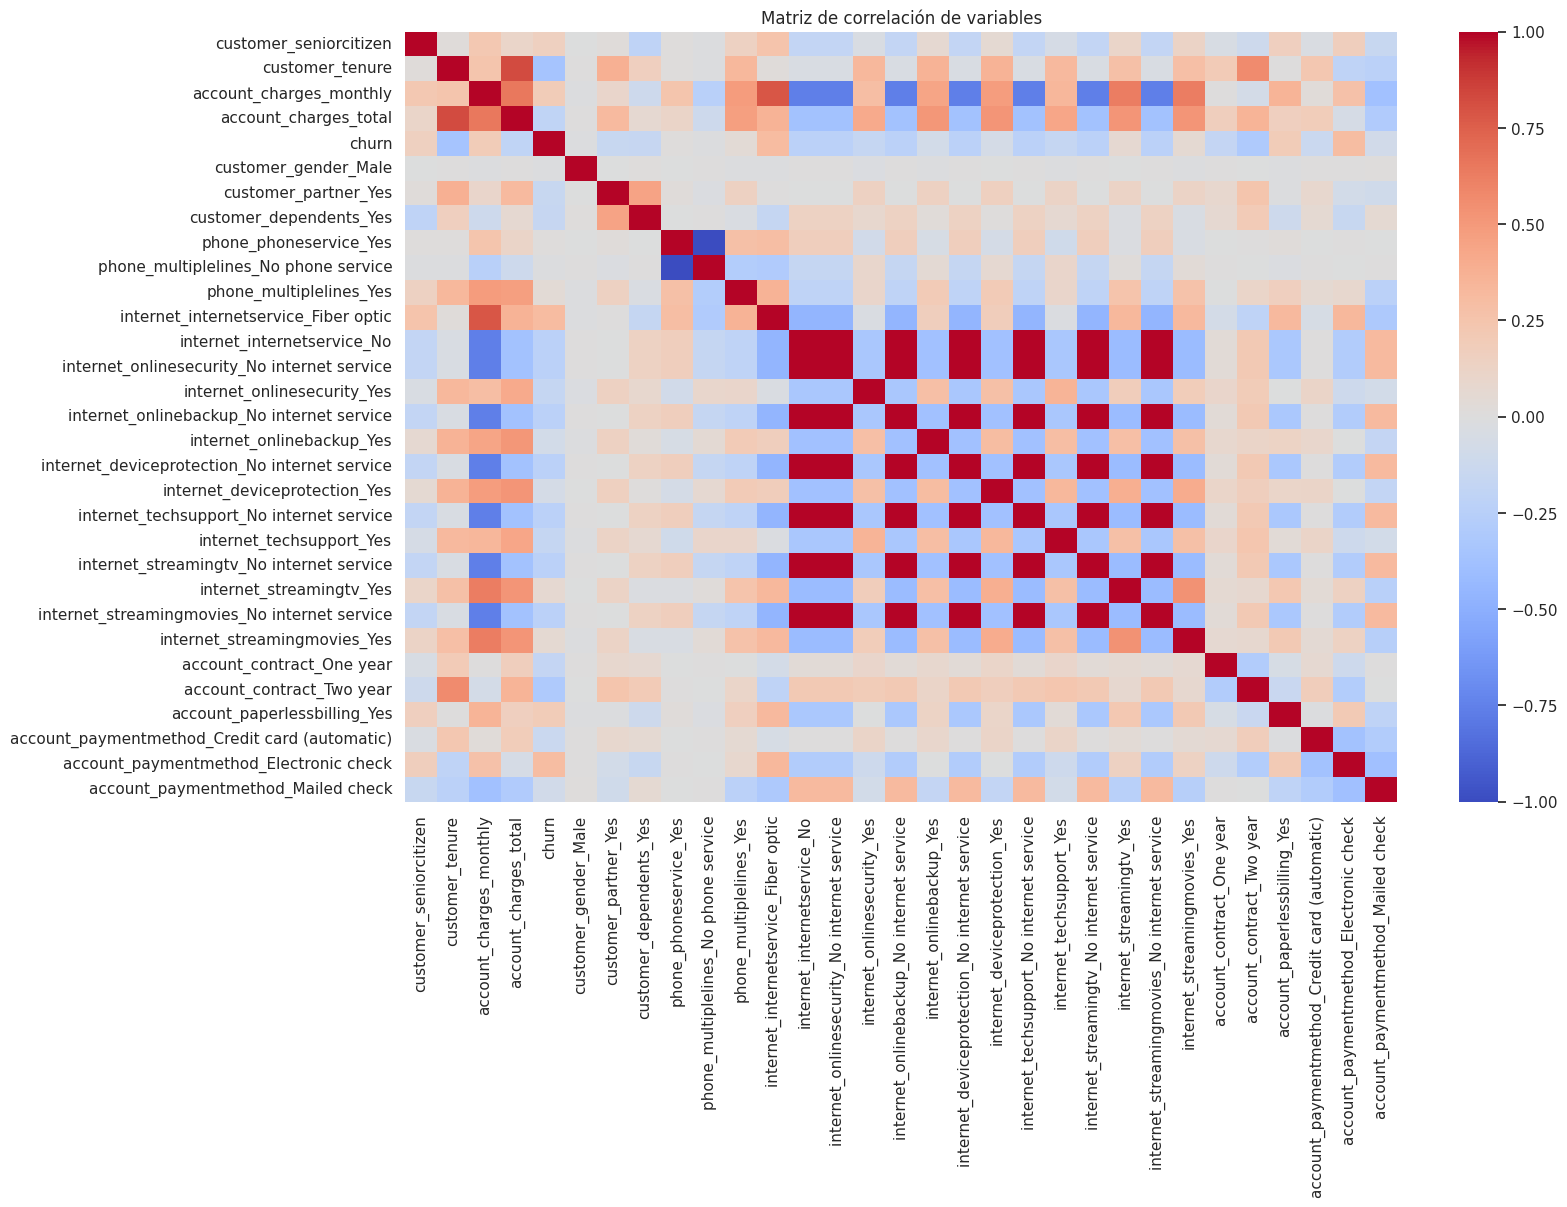

In [26]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Matriz de correlación de variables")
plt.show()

La matriz es muy grande y no muy clara, entonces reducimos a las variables que están más relacionadas con churn unicamente.

##Visualizar qué variables están más relacionadas con la evasión (churn)

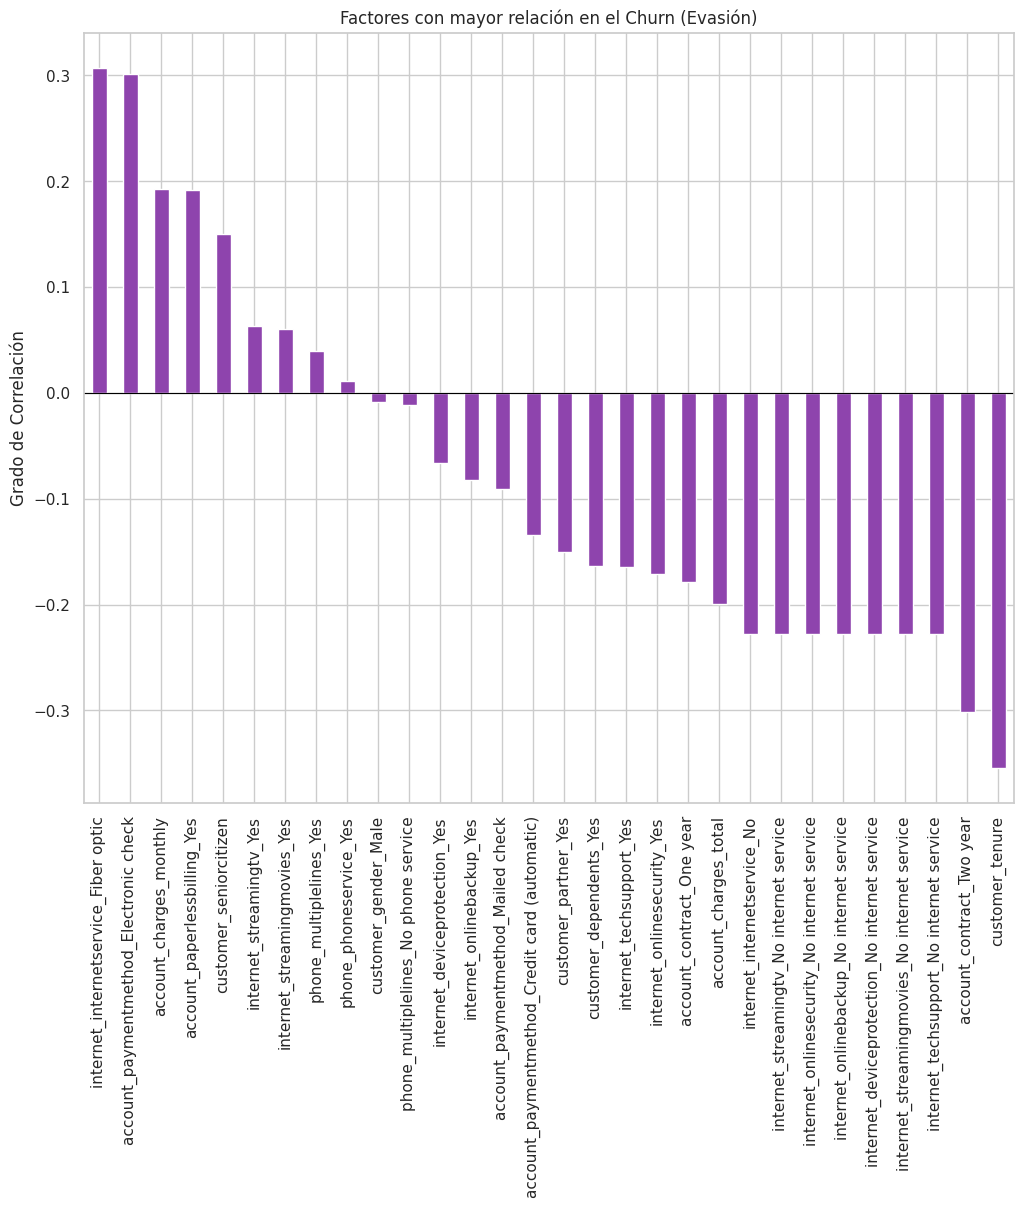

In [35]:
#Graficamos
plt.figure(figsize=(12, 10))

# Usamos numeric_only=True para que tome los valores True/False como 1/0
correlacion = df.corr(numeric_only=True)['churn'].sort_values(ascending=False)


# Graficamos
correlacion.drop('churn').plot(kind='bar', color='#8e44ad')
plt.title("Factores con mayor relación en el Churn (Evasión)")
plt.ylabel("Grado de Correlación")
plt.axhline(0, color='black', linewidth=0.8) # Línea base en 0, separa correlación positiva y negativa
plt.xticks(rotation=90)
plt.show()

###Correlación positiva (aumentan evasión de clientes)

Estas variables se asocian con tener mayor probabilidad de cancelación.

| Variable                      | Correlación | Interpretación                                       |
| ----------------------------- | ----------- | ---------------------------------------------------- |
| `customer_tenure`             | **-0.354**  | Clientes con más tiempo en la empresa cancelan menos |
| `account_contract_Two year`   | **-0.302**  | Contratos de dos años reducen churn                  |
| `internet_internetservice_No` | **-0.228**  | Clientes sin internet cancelan menos                 |
| `account_contract_One year`   | **-0.178**  | Contratos de un año también reducen churn            |
| `customer_dependents_Yes`     | **-0.163**  | Clientes con dependientes cancelan menos             |
| `customer_partner_Yes`        | **-0.150**  | Clientes con pareja cancelan menos                   |




Clientes con mayor antigüedad y contratos más largos tienden a quedarse.

###Correlación negativa (reducen evasón de clientes)

Estas variables están asociadas con mayor permanencia de clientes.

| Variable                      | Correlación | Interpretación                                       |
| ----------------------------- | ----------- | ---------------------------------------------------- |
| `customer_tenure`             | **-0.354**  | Clientes con más tiempo en la empresa cancelan menos |
| `account_contract_Two year`   | **-0.302**  | Contratos de dos años reducen churn                  |
| `internet_internetservice_No` | **-0.228**  | Clientes sin internet cancelan menos                 |
| `account_contract_One year`   | **-0.178**  | Contratos de un año también reducen churn            |
| `customer_dependents_Yes`     | **-0.163**  | Clientes con dependientes cancelan menos             |
| `customer_partner_Yes`        | **-0.150**  | Clientes con pareja cancelan menos                   |


**Las variables que más se relacionan positivamente con el churn son principlamente:**

-uso de internet por fibra óptica

-método de pago mediante cheque electrónico

-cargos mensuales más elevados

Para estos clientes es más probable abandonar los servicios.



**Las correlaciones negativas más fuertes:**

-antigüedad del cliente (tenure)

-contratos de largo plazo, especialmente los contratos de dos años.

Esto indica que los clientes que llevan más tiempo en la empresa o que cuentan con contratos más largos tienden a permanecer en el servicio.

##Relación de churn y tiempo de contrato/gasto total

In [39]:
df["estado_churn"] = df["churn"].map({False: "No canceló", True: "Canceló"})

###Tiempo de contrato (tenure) × churn

/tmp/ipykernel_590/2848753151.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No canceló", "Canceló"])
/tmp/ipykernel_590/2848753151.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No canceló", "Canceló"])


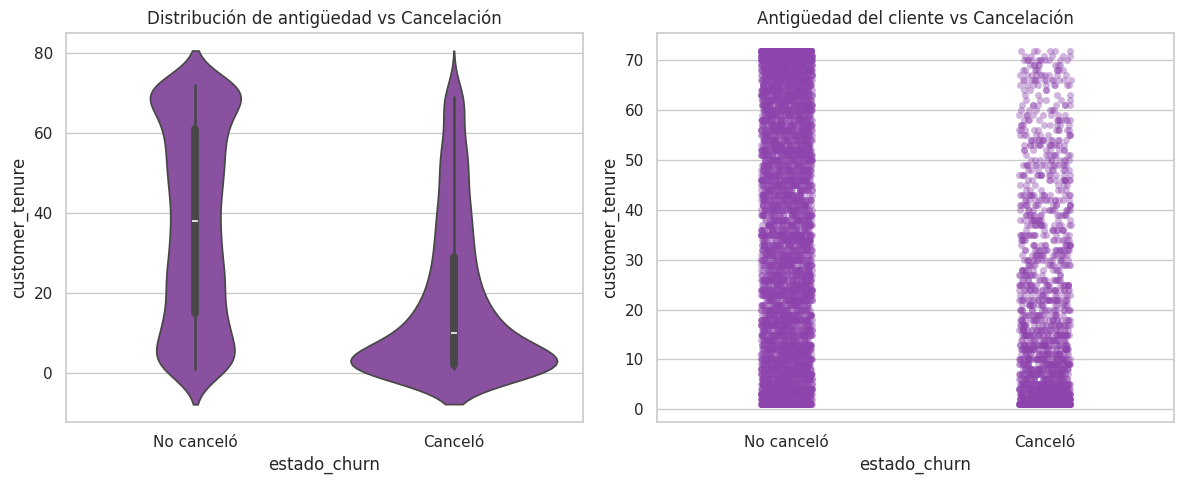

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Violin plot
sns.violinplot(
    x="estado_churn",
    y="customer_tenure",
    data=df,
    ax=axes[0],
    color="#8e44ad"
)

axes[0].set_title("Distribución de antigüedad vs Cancelación")
axes[0].set_xticklabels(["No canceló", "Canceló"])

# Scatter plot
sns.stripplot(
    x="estado_churn",
    y="customer_tenure",
    data=df,
    ax=axes[1],
    color="#8e44ad",
    alpha=0.4,
    jitter=True
)

axes[1].set_title("Antigüedad del cliente vs Cancelación")
axes[1].set_xticklabels(["No canceló", "Canceló"])

plt.tight_layout()
plt.show()

###Gasto total × churn

/tmp/ipykernel_590/3205491204.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No canceló", "Canceló"])
/tmp/ipykernel_590/3205491204.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No canceló", "Canceló"])


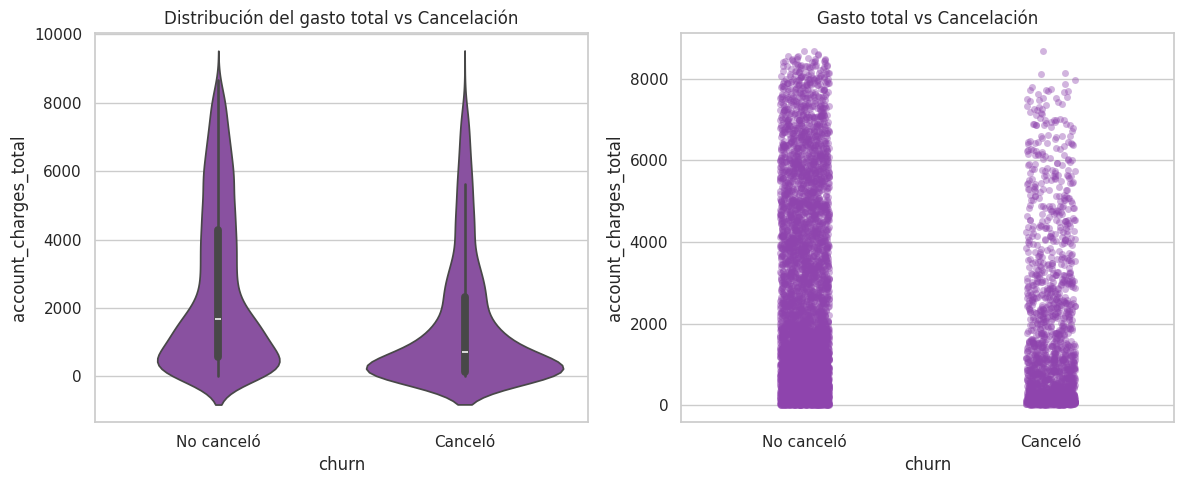

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Violin plot
sns.violinplot(
    x="churn",
    y="account_charges_total",
    data=df,
    ax=axes[0],
    color="#8e44ad"
)

axes[0].set_title("Distribución del gasto total vs Cancelación")
axes[0].set_xticklabels(["No canceló", "Canceló"])

# Scatter plot
sns.stripplot(
    x="churn",
    y="account_charges_total",
    data=df,
    ax=axes[1],
    color="#8e44ad",
    alpha=0.4,
    jitter=True
)

axes[1].set_title("Gasto total vs Cancelación")
axes[1].set_xticklabels(["No canceló", "Canceló"])

plt.tight_layout()
plt.show()

# 🤖 3. Division de datos para Modelado Predictivo



El conjunto de datos se dividió en dos subconjuntos: uno para entrenamiento y otro para prueba.

Se utilizó una división de 80% de los datos para entrenamiento y 20% para prueba, permitiendo que el modelo aprenda patrones a partir del conjunto de entrenamiento y posteriormente sea evaluado con datos que no ha visto previamente.

Además, se utilizó el parámetro stratify para mantener la misma proporción de clientes que cancelan y que no cancelan en ambos subconjuntos, evitando así introducir sesgos en el proceso de evaluación del modelo.

| Conjunto                  | Uso                              |
| ------------------------- | -------------------------------- |
| **Entrenamiento (train)** | donde el modelo aprende patrones |
| **Prueba (test)**         | donde evaluamos el desempeño     |


In [48]:
from sklearn.model_selection import train_test_split
# Dividimos 70% entrenamiento y 30% prueba
X = df.drop("churn", axis=1)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

Muestras de entrenamiento: 5625
Muestras de prueba: 1407


Verificamos que la división se realizó correctamente.

In [49]:
print(X_train.shape)
print(X_test.shape)

(5625, 31)
(1407, 31)


# 🤖 4. Creación de Modelos
Dos modelos a realizar:
1. **Regresión Logística**: Un modelo lineal que requiere datos normalizados.
2. **Árbol de decisión**: Un modelo que usa divisiones con reglas, usa los datos originales, es decir que no requiere normalización.

##Modelo 1 — Regresión Logística (con normalización)

In [55]:
#excluímos la columna estado churn que se había usado para los gráficos
X = df.drop(["churn", "estado_churn"], axis=1)
y = df["churn"]

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


###Normalización para regresión logística

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###Entrenamiento del modelo de Regresión Logística

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

#Creamos y entrenamos el modelo con datos estandarizados.

modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(X_train_scaled, y_train)

# Realizamos predicciones
y_pred_log = modelo_logistico.predict(X_test_scaled)





###Evaluación inicial del modelo logístico

In [61]:
# Evaluación inicial
print("--- MÉTRICAS: REGRESIÓN LOGÍSTICA ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_log):.4f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_log))

--- MÉTRICAS: REGRESIÓN LOGÍSTICA ---
Exactitud (Accuracy): 0.8017

Informe de Clasificación:
              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1033
        True       0.66      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



###Matriz de Confusión-Modelo de Regresión logística

In [69]:
cm_log = confusion_matrix(y_test, y_pred_log)

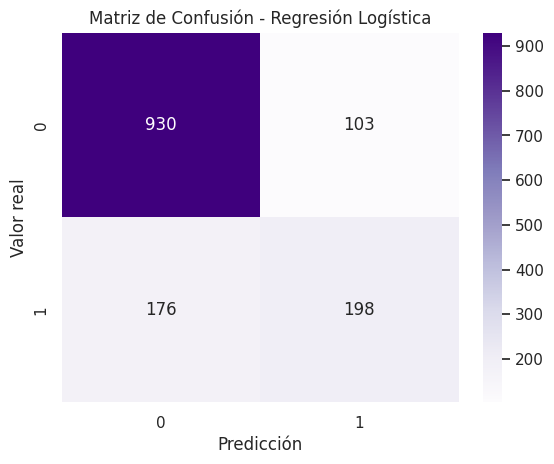

In [70]:
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Purples")

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

Esta primera evaluación del modelo nos dice que este pierde aproximadamente el 47% de los clientes que cancelan.

Esto puede ser un problema si la empresa quiere anticipar cancelaciones para desarrollar estrategias para que los clientes se queden.
El modelo es mejor identificando clientes que se quedan que clientes que se van.
Esto ocurre porque hay más clientes que se quedan en nuestra distribución: False (73%)

El modelo aprende más patrones de esa clase.

##Modelo 2 — Árbol de decisiones (sin normalización)

###Entrenamiento del modelo de Árbol de Decisiones

In [65]:
#importamos el modelo
from sklearn.tree import DecisionTreeClassifier
#creamos el modelo
tree_model = DecisionTreeClassifier(random_state=42)
#entrenamos el modelo
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [66]:
#predicciones
y_pred_tree = tree_model.predict(X_test)

In [67]:
#calculamos exactitud
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("\n--- MÉTRICAS: ÁRBOL DE DECISIÓN ---")
print(f"Exactitud (Accuracy): {accuracy_tree:.4f}")


--- MÉTRICAS: ÁRBOL DE DECISIÓN ---
Exactitud (Accuracy): 0.7171


In [72]:
#Evaluación inicial
from sklearn.metrics import classification_report
print("\nInforme de Clasificación - Árbol de Decisión:")
print(classification_report(y_test, y_pred_tree))


Informe de Clasificación - Árbol de Decisión:
              precision    recall  f1-score   support

       False       0.81      0.81      0.81      1033
        True       0.47      0.47      0.47       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407



###Matriz de Confusión-Modelo de Árbol de Decisión

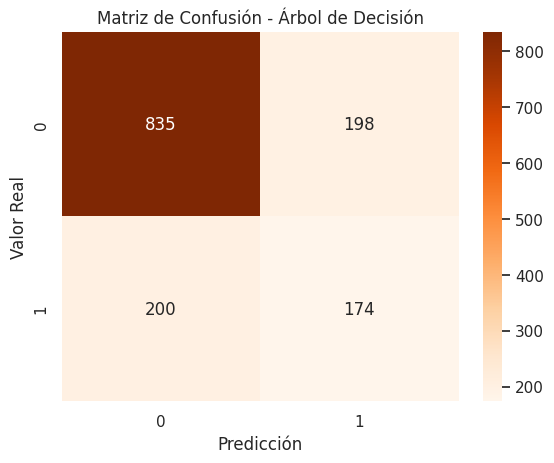

In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tree)

sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

##Comparación inicial de Modelos

| Métrica               | Regresión Logística | Árbol de Decisión |
| --------------------- | ------------------- | ----------------- |
| **Accuracy**          | **0.80**            | 0.72              |
| **Precision (churn)** | **0.66**            | 0.47              |
| **Recall (churn)**    | **0.53**            | 0.47              |
| **F1-score (churn)**  | **0.59**            | 0.47              |



###Matriz de confusión de ambos modelos

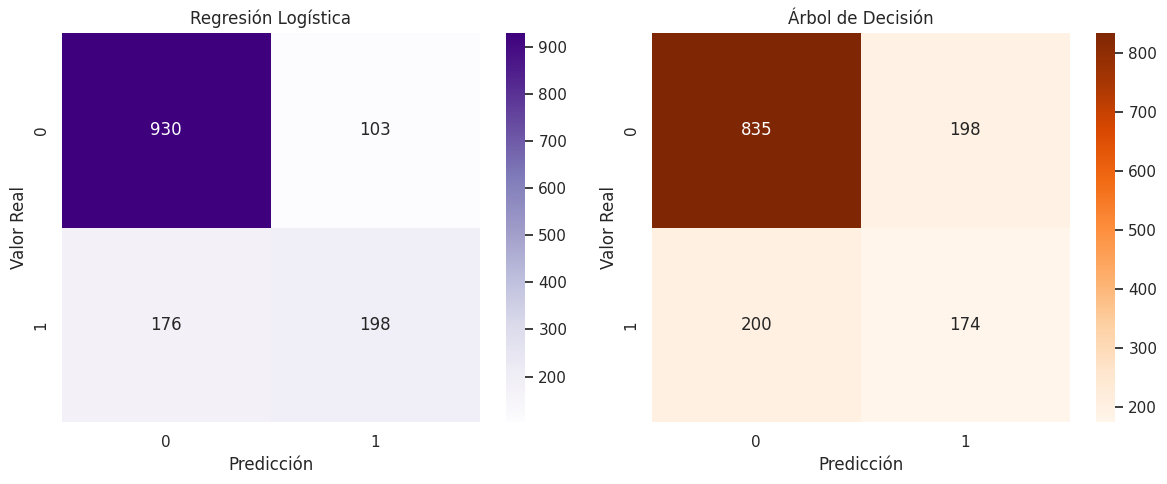

In [74]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Crear matrices
cm_log = confusion_matrix(y_test, y_pred_log)
cm_tree = confusion_matrix(y_test, y_pred_tree)

# Crear figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Matriz Regresión Logística
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Purples", ax=axes[0])
axes[0].set_title("Regresión Logística")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Valor Real")

# Matriz Árbol de Decisión
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Oranges", ax=axes[1])
axes[1].set_title("Árbol de Decisión")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Valor Real")

plt.tight_layout()
plt.show()

Las matrices de confusión permiten comparar visualmente el desempeño de ambos modelos. Se observa que la regresión logística identifica correctamente una mayor cantidad de clientes que cancelan el servicio en comparación con el árbol de decisión, lo que refuerza su mejor desempeño para este problema de predicción de churn.

##Resultado de evaluación de modelos:




Se evaluaron dos modelos de clasificación para predecir la cancelación de clientes: Regresión Logística y Árbol de Decisión. Para comparar su desempeño se utilizaron las métricas accuracy, precision, recall, F1-score y la matriz de confusión.

Los resultados obtenidos fueron los siguientes:

| Modelo                  | Accuracy | Precision (churn) | Recall (churn) | F1-score (churn) |
| ----------------------- | -------- | ----------------- | -------------- | ---------------- |
| **Regresión Logística** | **0.80** | **0.66**          | **0.53**       | **0.59**         |
| Árbol de Decisión       | 0.72     | 0.47              | 0.47           | 0.47             |


El modelo de regresión logística detecta más los clientes que se van.
| Modelo              | Recall churn |
| ------------------- | ------------ |
| Regresión Logística | **0.53**     |
| Árbol de Decisión   | 0.47         |



A partir de estos resultados, se observa que la Regresión Logística presentó el mejor desempeño general, alcanzando una mayor exactitud y mejores valores en las métricas de clasificación para la clase de churn. Esto indica que el modelo logra identificar con mayor precisión a los clientes que cancelan el servicio.

Por otro lado, el Árbol de Decisión mostró un desempeño inferior, especialmente en la identificación de clientes que cancelan el servicio, reflejado en un menor recall y F1-score para la clase de churn.

En cuanto al comportamiento de los modelos, el árbol de decisión podría presentar cierto grado de overfitting, ya que este tipo de modelo tiende a ajustarse demasiado a los datos de entrenamiento cuando no se controla su complejidad (por ejemplo, limitando la profundidad del árbol o el número mínimo de muestras por nodo). Esto puede afectar su capacidad de generalización en nuevos datos.

En contraste, la Regresión Logística mostró un comportamiento más estable, lo que sugiere que logra capturar adecuadamente las tendencias generales del conjunto de datos sin ajustarse en exceso.

En conclusión, para este problema de predicción de churn, la Regresión Logística resulta ser el modelo más adecuado entre los evaluados, ya que presenta un mejor equilibrio entre precisión y capacidad de generalización.

# 📋 5. Interpretación de Resultados y Conclusiones
Análisis de  qué variables son más importantes para cada modelo.

##Importancia de las Variables Modelo de Regresión Logística

In [76]:
import pandas as pd

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_logistico.coef_[0]
})

coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

coeficientes.head(10)

,Variable,Coeficiente
3,account_charges_total,0.611552
10,internet_internetservice_Fiber optic,0.586406
21,internet_streamingtv_Yes,0.216805
26,account_paperlessbilling_Yes,0.181248
28,account_paymentmethod_Electronic check,0.167630
23,internet_streamingmovies_Yes,0.148202
9,phone_multiplelines_Yes,0.146953
0,customer_seniorcitizen,0.093951
17,internet_deviceprotection_Yes,0.035390
8,phone_multiplelines_No phone service,0.016550


###Las variables con mayor influencia positiva:
| Variable                                   | Interpretación                                                       |
| ------------------------------------------ | -------------------------------------------------------------------- |
| **account_charges_total**                  | clientes con mayor gasto total tienen mayor probabilidad de cancelar |
| **internet_internetservice_Fiber optic**   | usuarios de fibra óptica presentan mayor churn                       |
| **internet_streamingtv_Yes**               | quienes tienen streaming TV cancelan más                             |
| **account_paperlessbilling_Yes**           | facturación electrónica se asocia con mayor churn                    |
| **account_paymentmethod_Electronic check** | pagar con cheque electrónico aumenta churn                           |
| **internet_streamingmovies_Yes**           | usuarios de streaming movies cancelan más                            |
| **phone_multiplelines_Yes**                | tener múltiples líneas se asocia con mayor churn                     |
| **customer_seniorcitizen**                 | clientes mayores presentan mayor probabilidad de cancelación         |


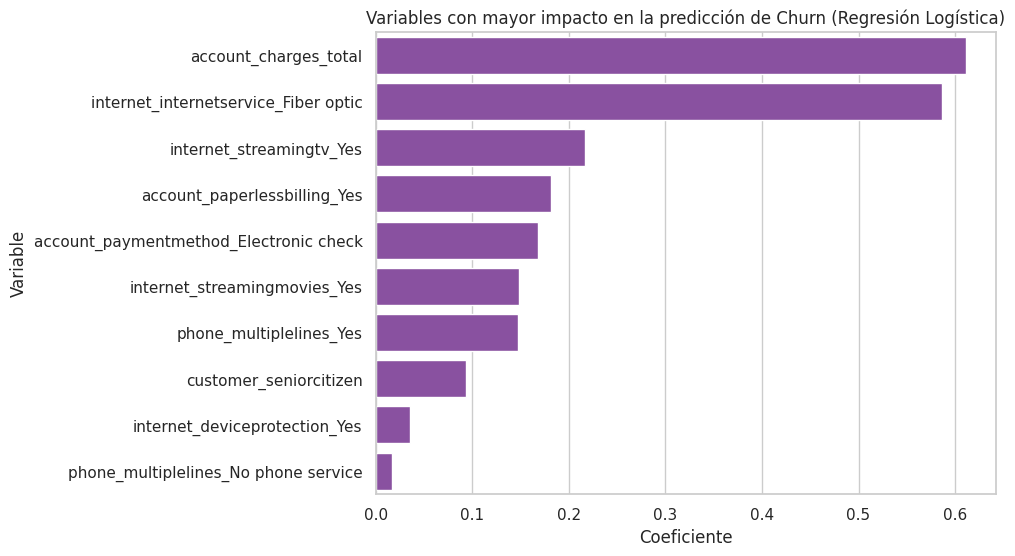

In [78]:
# Ordenar coeficientes
coeficientes_sorted = coeficientes.sort_values(by="Coeficiente", ascending=False)

# Seleccionar las 10 variables más influyentes
top_coef = coeficientes_sorted.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_coef,
    x="Coeficiente",
    y="Variable",
    color="#8e44ad"
)

plt.title("Variables con mayor impacto en la predicción de Churn (Regresión Logística)")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")

plt.show()

##Importancia de las Variables Modelo de Árbol de Decisiones

In [77]:
importances = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": tree_model.feature_importances_
})

importances = importances.sort_values(by="Importancia", ascending=False)

importances.head(10)

,Variable,Importancia
3,account_charges_total,0.201990
2,account_charges_monthly,0.200195
1,customer_tenure,0.192687
10,internet_internetservice_Fiber optic,0.108644
4,customer_gender_Male,0.029236
28,account_paymentmethod_Electronic check,0.023615
6,customer_dependents_Yes,0.022275
26,account_paperlessbilling_Yes,0.021847
5,customer_partner_Yes,0.021383
15,internet_onlinebackup_Yes,0.017309


###Las variables con mayor influencia:

| Variable                                   | Importancia | Interpretación                                                       |
| ------------------------------------------ | ----------- | -------------------------------------------------------------------- |
| **account_charges_total**                  | 0.2019      | clientes con mayor gasto total tienen mayor probabilidad de cancelar |
| **account_charges_monthly**                | 0.2002      | clientes con cargos mensuales altos presentan mayor churn            |
| **customer_tenure**                        | 0.1927      | la antigüedad del cliente influye fuertemente en la cancelación      |
| **internet_internetservice_Fiber optic**   | 0.1086      | usuarios con fibra óptica muestran mayor probabilidad de churn       |
| **customer_gender_Male**                   | 0.0292      | el género masculino aparece con cierta influencia en el modelo       |
| **account_paymentmethod_Electronic check** | 0.0236      | pagar con cheque electrónico se asocia con mayor churn               |
| **customer_dependents_Yes**                | 0.0223      | tener dependientes influye ligeramente en la cancelación             |
| **account_paperlessbilling_Yes**           | 0.0218      | facturación electrónica aparece asociada al churn                    |
| **customer_partner_Yes**                   | 0.0214      | tener pareja influye ligeramente en la permanencia/cancelación       |
| **internet_onlinebackup_Yes**              | 0.0173      | el servicio de respaldo en línea tiene impacto menor en el modelo    |


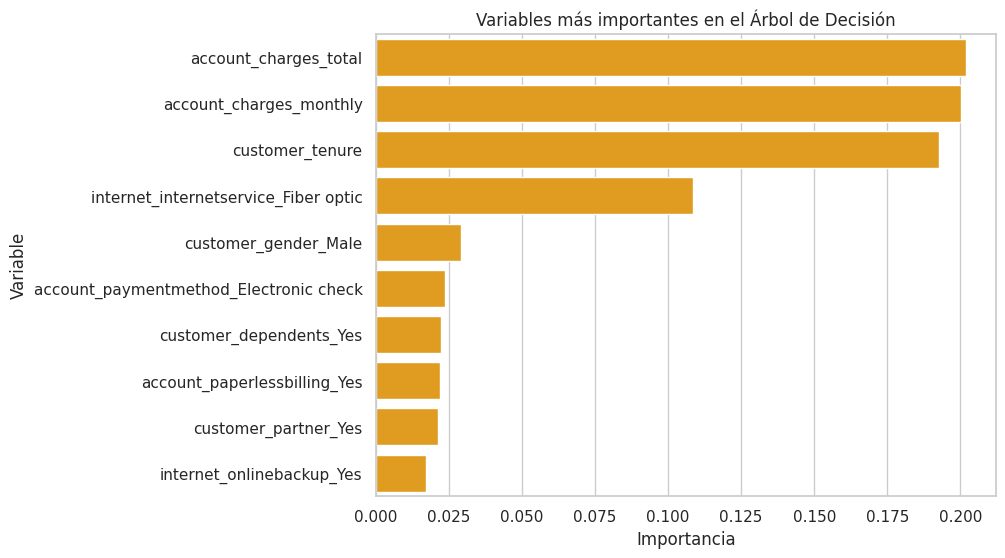

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data=importances.head(10),
    x="Importancia",
    y="Variable",
    color="orange"
)

plt.title("Variables más importantes en el Árbol de Decisión")
plt.show()

##Resultados: Variables importantes en los modelos.

El análisis de importancia de variables en los modelos de Regresión Logística y Árbol de Decisión permitió identificar los factores que tienen mayor influencia en la cancelación de clientes.

En ambos modelos destacan variables relacionadas con el costo del servicio, la antigüedad del cliente y el tipo de servicio contratado. En particular, variables como account_charges_total, account_charges_monthly, customer_tenure y internet_internetservice_Fiber optic aparecen entre las más relevantes para predecir la cancelación.

Asimismo, factores asociados a la forma de pago y facturación, como account_paymentmethod_Electronic check y account_paperlessbilling_Yes, también muestran una influencia significativa en el churn, lo que sugiere que ciertos métodos de pago pueden estar asociados con una mayor probabilidad de cancelación.

La coincidencia de estas variables en diferentes modelos refuerza la evidencia de que el nivel de gasto del cliente, la duración de la relación con la empresa y las características del servicio contratado son factores clave para explicar la cancelación de clientes en Telecom X.

#Informe Final

##Objetivo

Para esta segunda parte del análiisis el objetivo fue identificar los factores que influyen en la cancelación de clientes (churn) en Telecom X y construir modelos predictivos capaces de anticipar qué clientes tienen mayor probabilidad de cancelar el servicio.

##Metodología

Para ello, se entrenaron dos modelos de clasificación: Regresión Logística y Árbol de Decisión. Ambos modelos fueron evaluados utilizando métricas como accuracy, precision, recall, F1-score y matriz de confusión.

##Resultados

Los resultados mostraron que el modelo de Regresión Logística presentó el mejor desempeño, alcanzando una exactitud cercana al 80%, mientras que el Árbol de Decisión obtuvo aproximadamente 72%. Además, la regresión logística mostró mejores resultados en la identificación de clientes que cancelan el servicio, lo que la convierte en el modelo más adecuado entre los evaluados para este problema.

A partir del análisis de importancia de variables en ambos modelos, se identificaron varios factores clave asociados con la cancelación de clientes.

###Principales factores que influyen en la evasión de clientes

Los resultados indican que la cancelación de clientes está influenciada principalmente por variables relacionadas con el nivel de gasto, el tipo de servicio contratado y la duración de la relación con la empresa.

Entre las variables más relevantes destacan:

account_charges_total y account_charges_monthly: clientes con mayores cargos presentan una mayor probabilidad de cancelar el servicio.

customer_tenure: la antigüedad del cliente es un factor importante; los clientes con menor tiempo en la empresa tienden a cancelar con mayor frecuencia.

internet_internetservice_Fiber optic: los clientes con servicio de fibra óptica muestran una mayor tendencia a cancelar el servicio.

account_paymentmethod_Electronic check: el método de pago mediante cheque electrónico se asocia con mayores tasas de churn.

account_paperlessbilling_Yes: la facturación electrónica también aparece relacionada con una mayor probabilidad de cancelación.

La coincidencia de estas variables en ambos modelos refuerza la idea de que los factores económicos y las características del servicio contratado tienen un papel central en la decisión de los clientes de abandonar el servicio.

#Conclusión

El modelo de Regresión Logística mostró el mejor desempeño para la predicción de churn, mientras que el análisis de variables permitió identificar factores clave relacionados con el nivel de gasto, el tipo de servicio contratado y la antigüedad del cliente.

Estos hallazgos pueden ayudar a Telecom X a desarrollar estrategias de retención más efectivas, enfocadas en los segmentos de clientes con mayor riesgo de cancelación, contribuyendo así a mejorar la satisfacción del cliente y reducir la pérdida de ingresos.

#Recomendaciones

A partir de los resultados obtenidos en el análisis y los modelos predictivos, se pueden proponer diversas acciones orientadas a disminuir la cancelación de clientes y mejorar la retención en Telecom X.

1. Fomentar relaciones de mayor duración con los clientes
El análisis muestra que la antigüedad del cliente es un factor clave en la cancelación, siendo los clientes más recientes quienes presentan mayor probabilidad de abandonar el servicio. Por ello, la empresa podría implementar incentivos para promover contratos de mayor duración, así como programas de fidelización dirigidos a clientes nuevos durante los primeros meses de servicio.

2. Evaluar la experiencia de los usuarios con el servicio de fibra óptica
Los resultados indican que los clientes que utilizan el servicio de fibra óptica presentan una mayor tendencia a cancelar. Esto podría estar relacionado con expectativas del servicio, percepción del precio o calidad de la conexión. Sería recomendable analizar con mayor detalle la experiencia de estos usuarios para identificar posibles áreas de mejora.

3. Revisar la relación entre precio y valor percibido del servicio
Las variables relacionadas con los cargos mensuales y totales se encuentran entre las más influyentes en la predicción de churn. Esto sugiere que el costo del servicio puede estar afectando la decisión de algunos clientes de cancelar. En este sentido, Telecom X podría considerar revisar la estructura de sus planes o desarrollar estrategias que refuercen la percepción de valor del servicio ofrecido.

4. Implementar estrategias específicas para clientes con mayor riesgo de cancelación
Dado que los modelos predictivos permiten identificar perfiles con mayor probabilidad de churn, la empresa podría utilizar esta información para desarrollar campañas de retención dirigidas a estos segmentos, ofreciendo beneficios personalizados o atención prioritaria.

5. Analizar los métodos de pago asociados con mayor cancelación
El método de pago mediante electronic check aparece relacionado con mayores tasas de cancelación. Sería conveniente investigar si este método está asociado a determinados perfiles de clientes o patrones de comportamiento, así como promover alternativas de pago automáticas que faciliten la permanencia en el servicio.